# Multi Classifier Iris

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import Data

In [4]:
df = sns.load_dataset('iris')
df.sample(7, random_state=0)
# df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
114,5.8,2.8,5.1,2.4,virginica
62,6.0,2.2,4.0,1.0,versicolor
33,5.5,4.2,1.4,0.2,setosa
107,7.3,2.9,6.3,1.8,virginica
7,5.0,3.4,1.5,0.2,setosa
100,6.3,3.3,6.0,2.5,virginica
40,5.0,3.5,1.3,0.3,setosa


# Check data has null existence

In [5]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

# Check all label

In [6]:
pd.unique(df.species)

array(['setosa', 'versicolor', 'virginica'], dtype=object)

# Encoding from name to number

In [1]:
# encode
y, class_names = pd.factorize(df.species, sort=True)
# class_names is like list (array)
# class_names type is 'pandas.core.indexes.base.Index'
print(type(class_names))
# print(y[40:60])   # Check some data
pd.unique(y)

NameError: name 'pd' is not defined

# Visualization

In [2]:
# sns.scatterplot(x="petal_length",y="petal_width", data=df, hue="species", style='species')
sns.pairplot(df,hue='species')
plt.show()

NameError: name 'sns' is not defined

# Prepare data

In [ ]:
X = df.drop('species', axis=1)
# y = df.species
# y.head()

# Nomalization

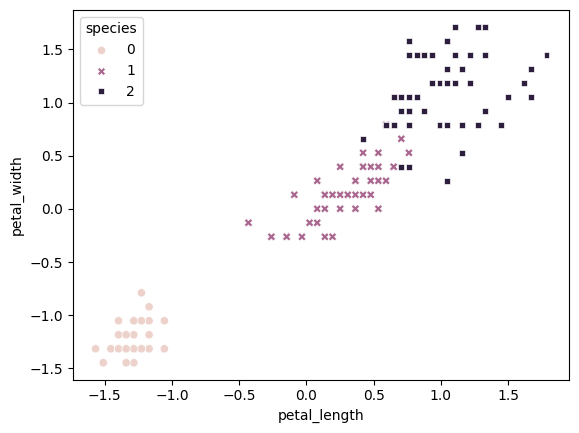

In [10]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
# # Nomalization
X_sc = sc.fit_transform(X)

# Convert numpy array to data frame
df_sc = pd.DataFrame(X_sc,columns=['sepal_length','sepal_width','petal_length','petal_width'])
df_sc['species'] = y 
sns.scatterplot(x="petal_length",y="petal_width", data=df_sc, hue="species", style='species')

plt.show()

# Split train data and test data

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_sc, y, test_size=0.25, random_state=1)

len(X_train),len(X_test)

(112, 38)

# Create model and train model

In [12]:
from sklearn.neural_network import MLPClassifier

model = MLPClassifier(hidden_layer_sizes=(4), max_iter=2500, verbose=True, random_state=1)
model.fit(X_train, y_train)

Iteration 1, loss = 0.99156143
Iteration 2, loss = 0.98950312
Iteration 3, loss = 0.98745473
Iteration 4, loss = 0.98541472
Iteration 5, loss = 0.98338322
Iteration 6, loss = 0.98136035
Iteration 7, loss = 0.97934619
Iteration 8, loss = 0.97734118
Iteration 9, loss = 0.97534562
Iteration 10, loss = 0.97335437
Iteration 11, loss = 0.97137044
Iteration 12, loss = 0.96939490
Iteration 13, loss = 0.96744232
Iteration 14, loss = 0.96550341
Iteration 15, loss = 0.96357349
Iteration 16, loss = 0.96165232
Iteration 17, loss = 0.95974671
Iteration 18, loss = 0.95786240
Iteration 19, loss = 0.95598683
Iteration 20, loss = 0.95411954
Iteration 21, loss = 0.95226146
Iteration 22, loss = 0.95041188
Iteration 23, loss = 0.94856917
Iteration 24, loss = 0.94673296
Iteration 25, loss = 0.94490972
Iteration 26, loss = 0.94310745
Iteration 27, loss = 0.94131073
Iteration 28, loss = 0.93951409
Iteration 29, loss = 0.93772097
Iteration 30, loss = 0.93593134
Iteration 31, loss = 0.93414475
Iteration 32, los

MLPClassifier(hidden_layer_sizes=4, max_iter=2500, random_state=1, verbose=True)

# Show result

In [13]:
from sklearn.metrics import classification_report, confusion_matrix

y_predict = model.predict(X_test)

print('score:', round(model.score(X_test,y_test),4))

print('annual y:', np.array(y_test))
print('predicted: ', model.predict(X_test))


print(classification_report(y_test, y_predict, target_names=class_names))
# matrix show each result
print(confusion_matrix(y_test, y_predict))

score: 0.9737
annual y: [0 1 1 0 2 1 2 0 0 2 1 0 2 1 1 0 1 1 0 0 1 1 1 0 2 1 0 0 1 2 1 2 1 2 2 0 1
 0]
predicted:  [0 1 1 0 2 1 2 0 0 2 1 0 2 1 1 0 1 1 0 0 1 1 2 0 2 1 0 0 1 2 1 2 1 2 2 0 1
 0]
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        13
  versicolor       1.00      0.94      0.97        16
   virginica       0.90      1.00      0.95         9

    accuracy                           0.97        38
   macro avg       0.97      0.98      0.97        38
weighted avg       0.98      0.97      0.97        38

[[13  0  0]
 [ 0 15  1]
 [ 0  0  9]]


# Show constructed model

In [14]:
[coef.shape for coef in model.coefs_]
# 4 inputs, 1 hidden layer (4 nodes), 3 outputs

[(4, 4), (4, 3)]

# Prediction

In [15]:
X_new = [[5.1,3.5,3.4,1.4],
         [6.1,3.5,3.9,1.6]]

# Prepare data before prediction
X_new_sc = sc.transform(X_new)
print(X_new_sc)

# Predict
y_pred = model.predict(X_new_sc)
# Inform the result
print(class_names[y_pred[1]])

[[-0.90068117  1.01900435 -0.20347799  0.26414192]
 [ 0.31099753  1.01900435  0.08070915  0.52740629]]
versicolor


c:\Users\UNS_CT\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


# Show model boundary

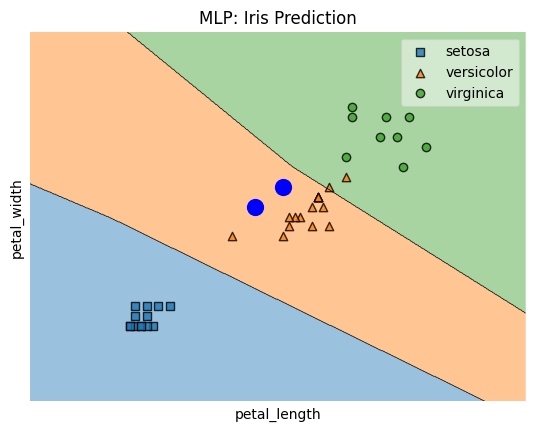

In [ ]:
from mlxtend.plotting import plot_decision_regions
value = 0
width = 3.5
# There is 4 feature so we should specfic 2 feature to check boundary
ax = plot_decision_regions(X_test, np.array(y_test), clf=model,
                           feature_index=[2,3],     # use feature index column 2,3
                           filler_feature_values = {0: value, 1: value},
                           filler_feature_ranges = {0: width, 1: width}, 
                           legend=2)
# label the classification
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles,class_names, framealpha=0.5)

plt.title('MLP: Iris Prediction')
plt.xlabel('petal_length')
plt.ylabel('petal_width')
plt.xticks([])
plt.yticks([])
plt.scatter(X_new_sc[:,2], X_new_sc[:,3], marker='o', s=130, c='b')
plt.show()